# Data Coverage

Summarise data coverage and mean LCC for the sites.

## Preparation

In [63]:
import copy

import xarray as xr

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from lcc_trend_analysis.paths import get_data_paths

from lcc_trend_analysis.observations.utils import (
    get_ground_sites_gdf,
)



In [64]:
sites = get_ground_sites_gdf()

analysis_sites = [
    "cabauw",
    "chilbolton",
    "flesland",
    "graciosa",
    "granada",
    "kenttarova",
    "juelich",
    "kumpula",
    "lauder",
    "lindenberg",
    "nsa",
    "oslo",
    "palaiseau",
    "payerne",
    "sgp",
    "vehmasmaki",
]
analysis_sites = sorted(
    analysis_sites, key=lambda site: sites.loc[site, "humanReadableName"]
)

In [65]:
figwidth = 20 / 2.56

font = {"size": 7}

mpl.rc("font", **font)

## Spatial coverage map

In [66]:
ceres_ds = xr.open_dataset(
    get_data_paths().ceres / "CERES_EBAF-TOA_Ed4.2.1_Subset_CLIM01-CLIM12.nc"
)

ceres_climatology_added_toa_sw_due_to_clouds = ceres_ds[
    "toa_sw_all_clim"
].mean(dim="ctime") - ceres_ds["toa_sw_clr_c_clim"].mean(dim="ctime")
ceres_climatology_added_toa_sw_due_to_clouds = (
    ceres_climatology_added_toa_sw_due_to_clouds.where(
        ceres_climatology_added_toa_sw_due_to_clouds > 0
    )
)

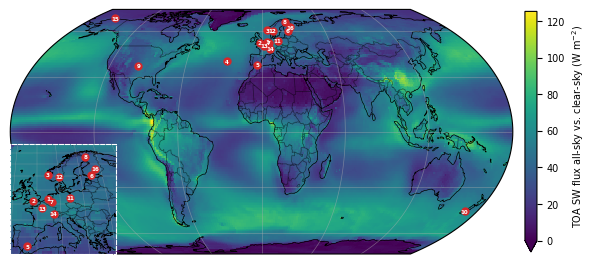

In [67]:
globe = ccrs.Globe(ellipse="WGS84")
crs = ccrs.Geodetic(globe=globe)
projection = ccrs.EqualEarth(globe=globe)

fig, ax = plt.subplots(
    1,
    1,
    figsize=(figwidth, figwidth * 0.5),
    subplot_kw={"projection": projection},
)

# Add map features
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)
ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5)

ceres_climatology_added_toa_sw_due_to_clouds.fillna(0.0).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    cbar_kwargs={
        "label": "TOA SW flux all-sky vs. clear-sky (W m$^{-2}$)",
        "shrink": 0.8,
        "pad": 0.02,
        "extend": "min",
    },
    vmin=0,
)


# Dictionary to store site information for legend
legend_info = []
site_number = 1

# Plot all sites
for site_id in analysis_sites:
    lat = sites.loc[site_id, "geometry"].y
    lon = sites.loc[site_id, "geometry"].x

    # Plot site marker
    ax.scatter(lon, lat, s=25, color="tab:red", transform=crs, zorder=5)

    # Add number annotation
    ax.text(
        lon,
        lat,
        f"{site_number}",
        transform=crs,
        fontsize=4,
        fontweight="bold",
        color="white",
        ha="center",
        va="center",
        zorder=6,
    )

    # Store legend info
    # legend_info.append(
    #    f"{site_number}. {sites.loc[site_id, 'humanReadableName']}, {sites.loc[site_id, 'countryCode']} ({first_year}-{last_year})"
    # )
    site_number += 1
# ax.set_extent([-180, 180, -80, 90], crs=ccrs.PlateCarree())
# ax.set_xticks([-180, -120, -60, 0, 60, 120, 180], crs=crs)
# ax.set_yticks([-60, -30, 0, 30, 60], crs=crs)


# Add zoomed-in inset for Europe

# Create inset axes in the upper right corner
ax_inset = inset_axes(
    ax,
    width="45%",
    height="45%",
    loc="lower left",
    bbox_to_anchor=(-0.12, 0.0, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
    axes_class=cartopy.mpl.geoaxes.GeoAxes,
    axes_kwargs=dict(projection=projection),
)

for spine in ax_inset.spines.values():
    spine.set_color("white")  # Set border color
    # spine.set_linewidth(2)       # Set border thickness
    spine.set_linestyle(
        "--"
    )  # Set border style (e.g., 'solid', 'dashed', 'dotted')

# Set extent for Europe
ax_inset.set_extent([-10, 30, 35, 75], crs=crs)

# Add features to inset
ax_inset.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
ax_inset.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.3)
ax_inset.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax_inset.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)
ax_inset.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)

ceres_climatology_added_toa_sw_due_to_clouds.plot(
    ax=ax_inset,
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    add_colorbar=False,
    vmin=0,
)

# Plot sites in inset
for i, site_id in enumerate(analysis_sites, 1):
    lat = sites.loc[site_id, "geometry"].y
    lon = sites.loc[site_id, "geometry"].x

    # Only plot if site is in Europe extent
    if -10 <= lon <= 35 and 35 <= lat <= 75:
        ax_inset.scatter(
            lon, lat, s=25, color="tab:red", transform=crs, zorder=5
        )
        ax_inset.text(
            lon,
            lat,
            f"{i}",
            transform=crs,
            fontsize=4,
            fontweight="bold",
            color="white",
            ha="center",
            va="center",
            zorder=6,
        )


# Add legend outside the plot
legend_text = "\n".join(legend_info)
fig.text(
    0.85,
    0.5,
    legend_text,
    fontsize=7,
    verticalalignment="center",
    family="sans",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
)

plt.savefig(
    get_data_paths().results / "alc_sites_map.png",
    dpi=300,
    bbox_inches="tight",
)

## Data coverage & mean LCC

In [93]:
mean_values = {
    "alc": {site: np.nan for site in analysis_sites},
    "era5/wmo": {site: np.nan for site in analysis_sites},
    "era5/isccp": {site: np.nan for site in analysis_sites},
    "ceres": {site: np.nan for site in analysis_sites}
}
mean_lcc_values = {
    "alc": [],
    "era5/wmo": [],
    "era5/isccp": [],
    "ceres": []
}
mean_lcc_values_midlatitude = copy.deepcopy(mean_lcc_values)
mean_lcc_values_highlatitude = copy.deepcopy(mean_lcc_values)
for site in analysis_sites:
    alc_value = xr.open_dataset(
        get_data_paths().level3_dataset("alc")
        / "clouds"
        / "alc_level3_clouds_mean_climatology.nc",
        group=f"{site}/shared_climatology"
    )["low_cloud_and_fog_cover"].item()
    mean_lcc_values["alc"].append(alc_value)
    era5_wmo_value =  xr.open_dataset(
        get_data_paths().level3_dataset("era5")
        / "clouds"
        / "era5_level3_clouds_mean_climatology.nc",
    ).sel(site=site)["low_cloud_and_fog_cover"].item()
    mean_lcc_values["era5/wmo"].append(era5_wmo_value)
    era5_isccp_value =  xr.open_dataset(
        get_data_paths().level3_dataset("era5")
        / "clouds"
        / "era5_level3_clouds_mean_climatology.nc",
    ).sel(site=site)["low_cloud_cover_isccp_non_obscured"].item()
    mean_lcc_values["era5/isccp"].append(era5_isccp_value)
    ceres_value =  xr.open_dataset(
        get_data_paths().level3_dataset("ceres")
        / "clouds"
        / "ceres_level3_clouds_mean_climatology.nc"
    ).sel(site=site)["low_cloud_cover_non_obscured_adj"].item()
    mean_lcc_values["ceres"].append(ceres_value)
    print(
        f"{site:<10}: ALC: {alc_value*100:.1f}, ERA5/WMO: {era5_wmo_value*100:.1f}, ERA5/CTP: {era5_isccp_value*100:.1f}, CERES: {ceres_value*100:.1f}"
    )
    
    if np.abs(sites.loc[site].geometry.y) <= 66.:
        mean_lcc_values_midlatitude["alc"].append(alc_value)
        mean_lcc_values_midlatitude["era5/wmo"].append(era5_wmo_value)
        mean_lcc_values_midlatitude["era5/isccp"].append(era5_isccp_value)
        mean_lcc_values_midlatitude["ceres"].append(ceres_value)
    else:
        mean_lcc_values_highlatitude["alc"].append(alc_value)
        mean_lcc_values_highlatitude["era5/wmo"].append(era5_wmo_value)
        mean_lcc_values_highlatitude["era5/isccp"].append(era5_isccp_value)
        mean_lcc_values_highlatitude["ceres"].append(ceres_value)

cabauw    : ALC: 43.2, ERA5/WMO: 39.6, ERA5/CTP: 36.2, CERES: 46.0
chilbolton: ALC: 48.9, ERA5/WMO: 43.9, ERA5/CTP: 39.6, CERES: 53.8
flesland  : ALC: 53.9, ERA5/WMO: 46.5, ERA5/CTP: 42.2, CERES: 63.2
graciosa  : ALC: 44.1, ERA5/WMO: 40.9, ERA5/CTP: 35.4, CERES: 64.4
granada   : ALC: 14.3, ERA5/WMO: 15.0, ERA5/CTP: 11.7, CERES: 22.4
kumpula   : ALC: 49.7, ERA5/WMO: 47.5, ERA5/CTP: 44.2, CERES: 56.8
juelich   : ALC: 42.9, ERA5/WMO: 39.2, ERA5/CTP: 35.9, CERES: 53.1
kenttarova: ALC: 43.5, ERA5/WMO: 52.3, ERA5/CTP: 47.8, CERES: 56.8
sgp       : ALC: 17.0, ERA5/WMO: 15.9, ERA5/CTP: 14.6, CERES: 26.1
lauder    : ALC: 25.4, ERA5/WMO: 40.1, ERA5/CTP: 34.8, CERES: 45.9
lindenberg: ALC: 40.1, ERA5/WMO: 36.7, ERA5/CTP: 34.9, CERES: 51.0
oslo      : ALC: 40.9, ERA5/WMO: 34.5, ERA5/CTP: 31.8, CERES: 58.4
palaiseau : ALC: 42.9, ERA5/WMO: 39.0, ERA5/CTP: 36.0, CERES: 47.5
payerne   : ALC: 37.6, ERA5/WMO: 40.1, ERA5/CTP: 33.1, CERES: 42.9
nsa       : ALC: 39.0, ERA5/WMO: 76.7, ERA5/CTP: 71.9, CERES: 

In [89]:
mean_of_means = {dataset: np.nanmean(values) for dataset, values in mean_lcc_values.items()}
print("Mean of mean low cloud cover across sites:")
for dataset, mean in mean_of_means.items():
    print(f"{dataset:<10}: {mean*100:.1f}")
    
print("\nMean bias between datasets (dataset1 - dataset2):")
datasets = list(mean_lcc_values.keys())
for i, dataset1 in enumerate(datasets):
    for dataset2 in datasets[i+1:]:
        biases = [v1 - v2 for v1, v2 in zip(mean_lcc_values[dataset1], mean_lcc_values[dataset2])]
        mean_bias = np.nanmean(biases) * 100
        print(f"{dataset1:<10} - {dataset2:<10}: {mean_bias:+.1f}%")

Mean of mean low cloud cover across sites:
alc       : 36.0
era5/wmo  : 41.4
era5/isccp: 37.5
ceres     : 51.3

Mean bias between datasets (dataset1 - dataset2):
alc        - era5/wmo  : -5.4%
alc        - era5/isccp: -1.5%
alc        - ceres     : -15.3%
era5/wmo   - era5/isccp: +3.8%
era5/wmo   - ceres     : -9.9%
era5/isccp - ceres     : -13.8%


In [91]:
mean_of_means_midlatitude = {dataset: np.nanmean(values) for dataset, values in mean_lcc_values_midlatitude.items()}
print("\nMean of mean low cloud cover across midlatitude sites:")
for dataset, mean in mean_of_means_midlatitude.items():
    print(f"{dataset:<10}: {mean*100:.1f}")

print("\nMean bias between datasets (dataset1 - dataset2) for midlatitude sites:")
datasets = list(mean_lcc_values_midlatitude.keys())
for i, dataset1 in enumerate(datasets):
    for dataset2 in datasets[i+1:]:
        biases = [v1 - v2 for v1, v2 in zip(mean_lcc_values_midlatitude[dataset1], mean_lcc_values_midlatitude[dataset2])]
        mean_bias = np.nanmean(biases) * 100
        print(f"{dataset1:<10} - {dataset2:<10}: {mean_bias:+.1f}%")


Mean of mean low cloud cover across midlatitude sites:
alc       : 35.7
era5/wmo  : 38.1
era5/isccp: 34.3
ceres     : 49.5

Mean bias between datasets (dataset1 - dataset2) for midlatitude sites:
alc        - era5/wmo  : -2.4%
alc        - era5/isccp: +1.4%
alc        - ceres     : -13.8%
era5/wmo   - era5/isccp: +3.7%
era5/wmo   - ceres     : -11.5%
era5/isccp - ceres     : -15.2%


In [92]:
mean_of_means_highlatitude = {dataset: np.nanmean(values) for dataset, values in mean_lcc_values_highlatitude.items()}
print("\nMean of mean low cloud cover across highlatitude sites:")
for dataset, mean in mean_of_means_highlatitude.items():
    print(f"{dataset:<10}: {mean*100:.1f}")
    
print("\nMean bias between datasets (dataset1 - dataset2) for highlatitude sites:")
datasets = list(mean_lcc_values_highlatitude.keys())
for i, dataset1 in enumerate(datasets):
    for dataset2 in datasets[i+1:]:
        biases = [v1 - v2 for v1, v2 in zip(mean_lcc_values_highlatitude[dataset1], mean_lcc_values_highlatitude[dataset2])]
        mean_bias = np.nanmean(biases) * 100
        print(f"{dataset1:<10} - {dataset2:<10}: {mean_bias:+.1f}%")


Mean of mean low cloud cover across highlatitude sites:
alc       : 38.0
era5/wmo  : 64.5
era5/isccp: 59.9
ceres     : 63.7

Mean bias between datasets (dataset1 - dataset2) for highlatitude sites:
alc        - era5/wmo  : -26.5%
alc        - era5/isccp: -21.8%
alc        - ceres     : -25.6%
era5/wmo   - era5/isccp: +4.7%
era5/wmo   - ceres     : +0.9%
era5/isccp - ceres     : -3.8%


In [72]:
ds_trends = xr.open_dataset(
    get_data_paths().level4_trends / "cloud_cover_trends.nc"
)

coverage_values = {
    "alc": [],
    "ceres": [],
    "record_length": [],
}
coverage_values_midlatitude = copy.deepcopy(coverage_values)
coverage_values_highlatitude = copy.deepcopy(coverage_values)
for site in analysis_sites:
    alc_value = ds_trends.alc_trend_n_samples.sel(site=site).values
    ceres_value = ds_trends.ceres_adj_trend_n_samples.sel(site=site).values
    era5_value = ds_trends.era5_trend_n_samples.sel(site=site).values
    coverage_values["alc"].append(alc_value / era5_value * 100)
    coverage_values["ceres"].append(ceres_value / era5_value * 100)
    factor = 31 if site in ["granada", "sgp"] else 3
    coverage_values["record_length"].append(era5_value / 365 * factor)
    if np.abs(sites.loc[site].geometry.y) <= 66.:
        coverage_values_midlatitude["alc"].append(alc_value / era5_value * 100)
        coverage_values_midlatitude["ceres"].append(ceres_value / era5_value * 100)
        coverage_values_midlatitude["record_length"].append(era5_value / 365 * factor)
    elif np.abs(sites.loc[site].geometry.y) > 66.:
        print(site)
        coverage_values_highlatitude["alc"].append(alc_value / era5_value * 100)
        coverage_values_highlatitude["ceres"].append(ceres_value / era5_value * 100)
        coverage_values_highlatitude["record_length"].append(era5_value / 365 * factor)
    print(
        f"{site:<10}: Total samples: {int(era5_value*3)}, ALC: {alc_value / era5_value * 100:.1f}, CERES: {ceres_value / era5_value * 100:.1f}, ERA5: {era5_value / 365 * factor:.1f}"
    )

cabauw    : Total samples: 7206, ALC: 98.7, CERES: 96.2, ERA5: 19.7
chilbolton: Total samples: 8583, ALC: 95.6, CERES: 96.8, ERA5: 23.5
flesland  : Total samples: 4149, ALC: 91.8, CERES: 93.5, ERA5: 11.4
graciosa  : Total samples: 4479, ALC: 100.0, CERES: 93.8, ERA5: 12.3
granada   : Total samples: 414, ALC: 97.1, CERES: 93.5, ERA5: 11.7
kumpula   : Total samples: 4437, ALC: 89.4, CERES: 93.8, ERA5: 12.2
juelich   : Total samples: 5562, ALC: 95.5, CERES: 95.1, ERA5: 15.2
kenttarova
kenttarova: Total samples: 6225, ALC: 79.8, CERES: 95.6, ERA5: 17.1
sgp       : Total samples: 864, ALC: 100.0, CERES: 96.9, ERA5: 24.5
lauder    : Total samples: 3723, ALC: 84.8, CERES: 92.7, ERA5: 10.2
lindenberg: Total samples: 4503, ALC: 100.0, CERES: 93.9, ERA5: 12.3
oslo      : Total samples: 4674, ALC: 99.7, CERES: 94.2, ERA5: 12.8
palaiseau : Total samples: 5499, ALC: 99.9, CERES: 95.0, ERA5: 15.1
payerne   : Total samples: 3747, ALC: 89.5, CERES: 92.6, ERA5: 10.3
nsa
nsa       : Total samples: 8601,

In [73]:
mean_coverage = {dataset: np.nanmean(values) for dataset, values in coverage_values.items()}
for dataset, mean in mean_coverage.items():
    print(f"{dataset:<10}: {mean:.1f}")

alc       : 94.8
ceres     : 94.6
record_length: 15.2


In [74]:
mean_coverage_midlatitude = {dataset: np.nanmean(values) for dataset, values in coverage_values_midlatitude.items()}
for dataset, mean in mean_coverage_midlatitude.items():
    print(f"{dataset:<10}: {mean:.1f}")

alc       : 95.7
ceres     : 94.4
record_length: 14.4


In [75]:
mean_coverage_highlatitude = {dataset: np.nanmean(values) for dataset, values in coverage_values_highlatitude.items()}
for dataset, mean in mean_coverage_highlatitude.items():
    print(f"{dataset:<10}: {mean:.1f}")

alc       : 88.3
ceres     : 96.2
record_length: 20.3


## Gantt of ALC coverage

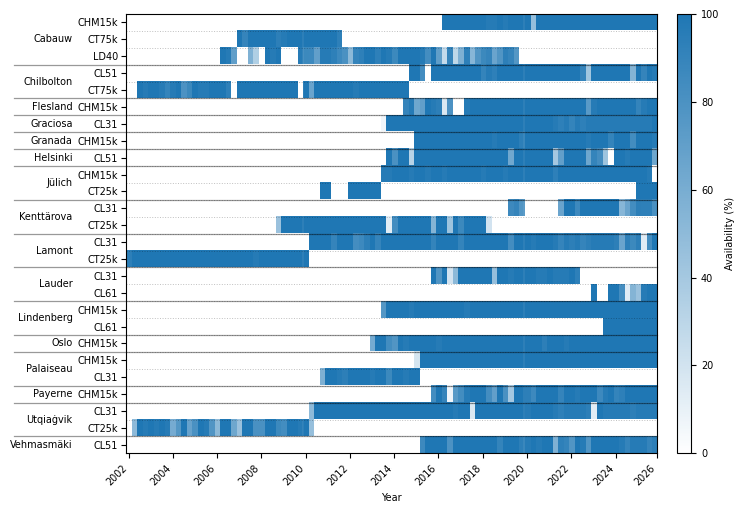

In [76]:
import numpy as np
import pandas as pd
from matplotlib import transforms
from xarray.core.treenode import group_subtrees

data_path = (
    get_data_paths().level3_clouds("alc") / "alc_level3_clouds_daily_raw.nc"
)
variable_name = "low_cloud_cover"

time_start = pd.Timestamp("2002-01-01")
time_end = pd.Timestamp("2026-01-01")
month_index = pd.date_range(time_start, time_end, freq="QS-DEC")

# Days per month over the analysis window (denominator for availability).
days_per_month = month_index.days_in_month.to_series(index=month_index).astype(
    float
)

sites = get_ground_sites_gdf()
site_name_lookup = {
    site_id: sites.loc[site_id, "humanReadableName"]
    if site_id in sites.index
    else site_id
    for site_id in analysis_sites
}

instrument_name_lookup = {
    "cl31": "CL31",
    "cl51": "CL51",
    "cl61": "CL61",
    "chm15k": "CHM15k",
    "ld40": "LD40",
    "ct25k": "CT25k",
    "ct75k": "CT75k",
}

records = []
with xr.open_datatree(data_path) as dtree:
    for path, (node,) in group_subtrees(dtree):
        if node.children:
            continue

        parts = [part for part in path.split("/") if part]
        if len(parts) < 2:
            continue

        site_id, instrument_id = parts[0], parts[1]
        if site_id not in analysis_sites:
            continue

        ds_node = node.dataset
        if (
            variable_name not in ds_node.data_vars
            or "time" not in ds_node[variable_name].coords
        ):
            continue

        da = ds_node[variable_name].sortby("time")
        time_values = pd.to_datetime(np.asarray(da.time.values))
        value_values = np.asarray(da.values, dtype=np.float64)

        valid_times = time_values[~np.isnan(value_values)]
        valid_times = valid_times[
            (valid_times >= time_start) & (valid_times <= time_end)
        ]

        valid_counts = pd.Series(1, index=valid_times).resample("MS").sum()
        availability = (
            100.0
            * valid_counts.reindex(month_index, fill_value=0).astype(float)
            / days_per_month
        ).clip(lower=0.0, upper=100.0)

        records.append(
            pd.DataFrame(
                {
                    "site_id": site_id,
                    "site_name": site_name_lookup.get(site_id, site_id),
                    "instrument_id": instrument_id,
                    "month": month_index,
                    "availability_pct": availability.values,
                }
            )
        )

if not records:
    raise ValueError(
        f"No instrument-resolved '{variable_name}' data found in {data_path}."
    )

df = pd.concat(records, ignore_index=True)
df = df.sort_values(["site_name", "instrument_id", "month"]).reset_index(
    drop=True
)

matrix = df.pivot_table(
    index=["site_name", "instrument_id"],
    columns="month",
    values="availability_pct",
    aggfunc="mean",
).reindex(columns=month_index)

n_rows = matrix.shape[0]
fig_height = max(4.5, 0.14 * n_rows + 1.5)
fig, ax = plt.subplots(figsize=(figwidth, fig_height))

cmap = mcolors.LinearSegmentedColormap.from_list(
    "blue",
    [
        mcolors.to_rgba("tab:blue", alpha=0),
        mcolors.to_rgba("tab:blue", alpha=1),
    ],
)

im = ax.imshow(
    matrix.values,
    aspect="auto",
    cmap=cmap,
    vmin=0,
    vmax=100,
    interpolation="nearest",
)

# X-axis: yearly ticks (include final 2026 at the right edge).
yearly_jan = pd.date_range("2002-01-01", "2026-01-01", freq="2YS")
year_tick_positions = month_index.searchsorted(yearly_jan).astype(float)

# Clamp ticks beyond available data to the right image edge so 2026 is shown.
year_tick_positions[year_tick_positions >= len(month_index)] = (
    len(month_index) - 0.5
)
year_tick_labels = yearly_jan.year

ax.set_xticks(year_tick_positions)
ax.set_xticklabels(year_tick_labels, rotation=45, ha="right")
ax.set_xlabel("Year")

# Add faint vertical guides every 5 years.
for pos, year in zip(year_tick_positions, year_tick_labels):
    if year % 5 == 0:
        ax.axvline(pos - 0.5, color="white", linewidth=0.35, alpha=0.25)

# Y-axis instrument labels (second index level).
ax.set_yticks(np.arange(n_rows))
ax.set_yticklabels(
    [
        instrument_name_lookup.get(id, id)
        for id in matrix.index.get_level_values("instrument_id")
    ],
)
ax.tick_params(axis="y", pad=2)

# Add site labels on the left and faint separators between site groups.
site_labels = matrix.index.get_level_values("site_name")
blend = transforms.blended_transform_factory(ax.transAxes, ax.transData)

for site_name in pd.unique(site_labels):
    row_positions = np.flatnonzero(site_labels == site_name)
    y_center = float(row_positions.mean())
    ax.text(
        -0.10,
        y_center,
        site_name,
        transform=blend,
        ha="right",
        va="center",
    )

# Separator between site blocks (instrument groups), drawn just left of the plot.
site_block_edges = np.where(site_labels[:-1] != site_labels[1:])[0]
for edge in site_block_edges:
    y = edge + 0.5
    ax.plot(
        [-0.21, 1],  # axes-fraction x (left of panel -> panel edge)
        [y, y],  # data y
        transform=blend,
        color="k",
        linewidth=0.9,
        alpha=0.4,
        clip_on=False,
        zorder=11,
    )

for edge in range(len(site_labels))[:-1]:
    ax.axhline(
        edge + 0.5,
        color="k",
        linestyle=":",
        linewidth=0.7,
        alpha=0.25,
        zorder=10,
    )

cbar = fig.colorbar(im, ax=ax, pad=0.03, aspect=30)
cbar.set_label("Availability (%)")

plt.tight_layout()
plt.savefig(
    get_data_paths().results / "alc_availability_gantt.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [77]:
np.where(site_labels[:-1] != site_labels[1:])[0]

array([ 2,  4,  5,  6,  7,  8, 10, 12, 14, 16, 18, 19, 21, 22, 24])